# Setup

In [10]:
!pip -q install ucimlrepo

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from ucimlrepo import fetch_ucirepo

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Dataset preparation

In [14]:
student = fetch_ucirepo(id=320)

X_all = student.data.features.copy()
y_all = student.data.targets.copy()

print(type(X_all))
print(type(y_all))
print(X_all.shape)
display(X_all.head())
display(y_all.head())

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
(649, 30)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [15]:
# Make sure we use G3 as the target
if hasattr(y_all, "columns") and "G3" in y_all.columns:
    y = y_all["G3"].copy()
else:
    y = y_all.squeeze().copy()

df = X_all.copy()
df["G3"] = y

print(df.shape)
print(df.columns.tolist())

(649, 31)
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']


In [16]:
features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
]

target = "G3"

data = df[features + [target]].copy()
data.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,18,4,4,2,2,0,4,3,4,1,1,3,4,11
1,17,1,1,1,2,0,5,3,3,1,1,3,2,11
2,15,1,1,1,2,0,4,3,2,2,3,3,6,12
3,15,4,2,1,3,0,3,2,2,1,1,5,0,14
4,16,3,3,1,2,0,4,3,2,1,2,5,0,13


In [17]:
data.to_csv("student_grades_numeric.csv", index=False)
print("Saved student_grades_numeric.csv")

Saved student_grades_numeric.csv


In [18]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000


# Dataset analize

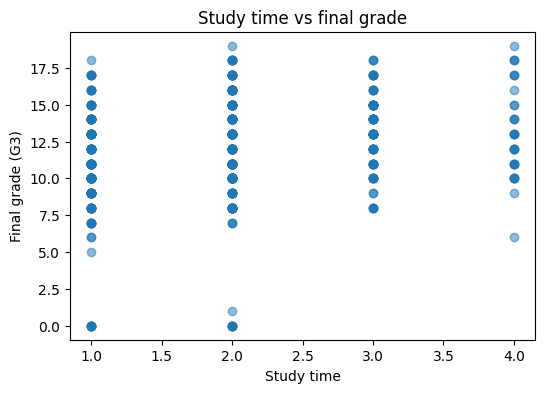

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(data["studytime"], data["G3"], alpha=0.5)
plt.xlabel("Study time")
plt.ylabel("Final grade (G3)")
plt.title("Study time vs final grade")
plt.show()

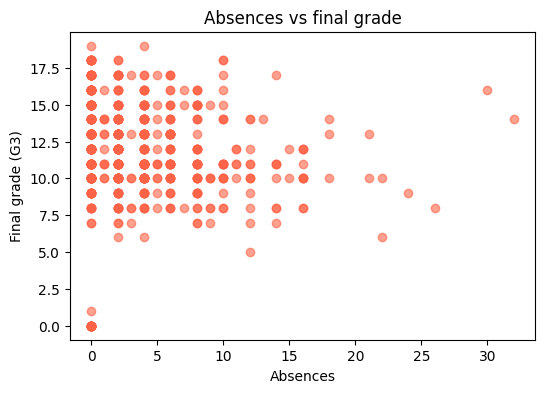

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(data["absences"], data["G3"], alpha=0.6, color="tomato")
plt.xlabel("Absences")
plt.ylabel("Final grade (G3)")
plt.title("Absences vs final grade")
plt.show()

# Model

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = data[features].values.astype(np.float32)
y = data[target].values.astype(np.float32).reshape(-1, 1)

# First split off the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Split the remaining part into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)
# 0.1765 of 85% is about 15% of the full dataset

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Val  :", X_val_tensor.shape, y_val_tensor.shape)
print("Test :", X_test_tensor.shape, y_test_tensor.shape)

Train: torch.Size([453, 13]) torch.Size([453, 1])
Val  : torch.Size([98, 13]) torch.Size([98, 1])
Test : torch.Size([98, 13]) torch.Size([98, 1])


In [26]:
class GradeRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

model = GradeRegressor(X_train_tensor.shape[1]).to(device)
print(model)

GradeRegressor(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


In [33]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 100
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # ---- training ----
    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- validation ----
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)
            running_val_loss += loss.item() * xb.size(0)

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d}/{num_epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f}"
        )

Epoch  10/100 | Train Loss: 5.7237 | Val Loss: 5.2360
Epoch  20/100 | Train Loss: 5.3715 | Val Loss: 6.4725
Epoch  30/100 | Train Loss: 5.1384 | Val Loss: 5.9973
Epoch  40/100 | Train Loss: 4.8621 | Val Loss: 5.9389
Epoch  50/100 | Train Loss: 4.7598 | Val Loss: 6.0823
Epoch  60/100 | Train Loss: 4.7727 | Val Loss: 6.0486
Epoch  70/100 | Train Loss: 5.6791 | Val Loss: 5.8764
Epoch  80/100 | Train Loss: 4.8838 | Val Loss: 6.1833
Epoch  90/100 | Train Loss: 4.6644 | Val Loss: 6.3239
Epoch 100/100 | Train Loss: 4.6257 | Val Loss: 6.3010


# Results

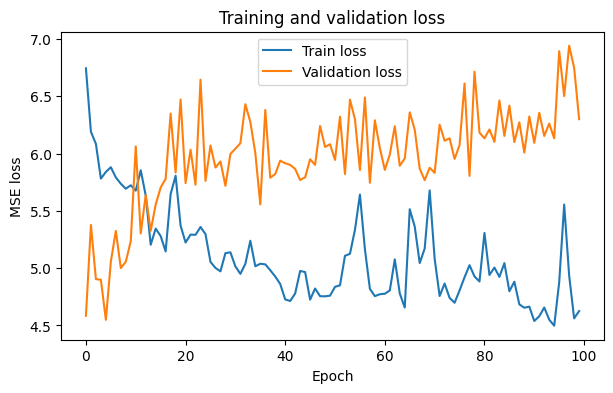

In [34]:
plt.figure(figsize=(7,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [35]:
model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor.to(device)).cpu()

y_pred = y_pred_tensor.numpy().flatten()
y_true = y_test_tensor.numpy().flatten()

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
r2 = r2_score(y_true, y_pred)

print("Test MAE :", round(mae, 2))
print("Test RMSE:", round(rmse, 2))
print("Test R^2 :", round(r2, 2))

Test MAE : 2.39
Test RMSE: 2.94
Test R^2 : 0.1


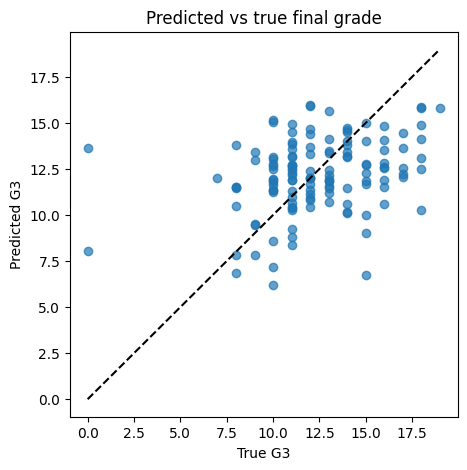

In [31]:
plt.figure(figsize=(5,5))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs true final grade")

lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, "k--")
plt.show()